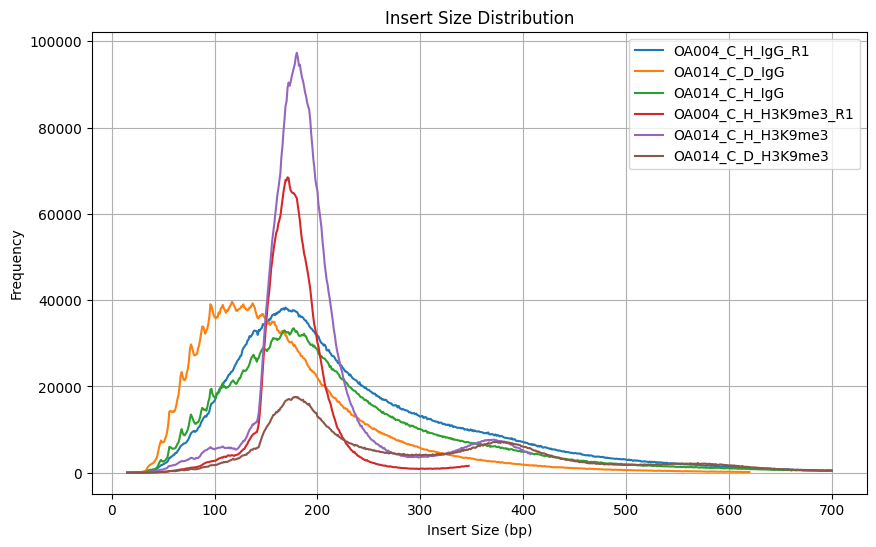

In [5]:
import matplotlib.pyplot as plt
import os

# Directory containing metrics files
metrics_dir = "/mnt/jw01-aruk-home01/projects/oa_functional_genomics/projects/CUT_RUN/analyses/CUT_RUN_pipeline/data/qc/insert_metrics"

# Function to parse Picard metrics file
def parse_metrics_file(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    # Find the histogram section
    histogram_start = None
    for i, line in enumerate(lines):
        if line.startswith("## HISTOGRAM"):
            histogram_start = i + 1
            break
    
    if histogram_start is None:
        print(f"Error: '## HISTOGRAM' section not found in file: {file_path}")
        return [], []  # Return empty lists to skip this file
    
    histogram_data = lines[histogram_start:]
    
    # Skip the header line (e.g., "insert_size	All_Reads.fr_count")
    x, y = [], []
    for line in histogram_data:
        if line.strip() and not line.startswith("insert_size"):  # Skip header
            fields = line.split()
            x.append(int(fields[0]))  # Insert size
            y.append(float(fields[1]))  # Count
    
    return x, y

# Plot overlay
plt.figure(figsize=(10, 6))

# Loop through all metrics files
for file_name in os.listdir(metrics_dir):
    if file_name.endswith("_insert_metrics.txt"):
        sample_name = file_name.replace("_insert_metrics.txt", "")
        file_path = os.path.join(metrics_dir, file_name)
        
        # Parse and plot
        x, y = parse_metrics_file(file_path)
        plt.plot(x, y, label=sample_name)

# Customize plot
plt.title("Insert Size Distribution")
plt.xlabel("Insert Size (bp)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

# Save the overlay plot
output_plot = os.path.join(metrics_dir, "overlay_insert_size_distribution.png")
plt.savefig(output_plot)
plt.show()